# Análisis: KPI´S

In [45]:
import pandas as pd
import os

# Construir ruta relativa
ruta = os.path.join('..', 'Data', 'TouristAccommodationClean19012026.csv')

# Leer CSV con encoding correcto
df = pd.read_csv(ruta, encoding='utf-8-sig')

# Ver primeras filas
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,high_quality_stay,month
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,FALSO,75.0,spain,malaga,2018-07-31,True,2018-07
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,FALSO,52.0,spain,madrid,2020-01-10,True,2020-01
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,2019-07-29,True,2019-07
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,2020-01-10,True,2020-01
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,FALSO,39.0,spain,girona,2019-02-19,True,2019-02


In [46]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'high_quality_stay', 'month'],
      dtype='object')

# Occupancy Rate = (Number of Occupied Days / Number of Days) × 100  /tasa de ocupación

In [47]:
# Tasa de ocupacion 
for period in ['30', '60', '90', '365']:
    print(f'\nOccupancy Rate {period} days:')
    print(
        ((int(period) - df[f"availability_{period}"]) / int(period)).mean()*100) #calcula dias ocupados para cada alojamiento/divide por el 
                                                                                                                                #total de dias
                                                                                #mean calcula la media de los alojamientos


Occupancy Rate 30 days:
59.07537018521164

Occupancy Rate 60 days:
54.30009998571632

Occupancy Rate 90 days:
50.77036613817074

Occupancy Rate 365 days:
48.45769586732228


# Promedio de ocupación por 30 dias de todos los alojamientos

# Crear la columna ocupacion de 30 dias 

In [55]:
df["occupancy_rate_30"] = ((30 - df["availability_30"]) / 30) * 100


In [56]:
promedio_30 = df["occupancy_rate_30"].mean()
print(f"Promedio de ocupación 30 días: {promedio_30:.2f}%")


Promedio de ocupación 30 días: 59.08%


In [57]:
# Promedio de ocupación por ciudad para 30 días
promedio_ciudad_30 = df.groupby("city")["occupancy_rate_30"].mean()
promedio_ciudad_30.round(2)


city
barcelona    63.11
girona       51.29
madrid       65.42
malaga       59.30
mallorca     55.01
menorca      50.09
sevilla      53.87
valencia     54.93
Name: occupancy_rate_30, dtype: float64

**Ciudad con mayor ocupacion** 

In [59]:
# Ciudad con mayor ocupación
ciudad_mayor_ocupacion = promedio_ciudad_30.idxmax()
valor_mayor_ocupacion = promedio_ciudad_30.max()

print(f"Ciudad con mayor ocupación promedio (30 días): {ciudad_mayor_ocupacion}")
print(f"Ocupación promedio: {valor_mayor_ocupacion:.2f}%")


Ciudad con mayor ocupación promedio (30 días): madrid
Ocupación promedio: 65.42%


**promedio de ocupación mensual**

**Ciudad y mes**

In [17]:
monthly_city = (
    df.groupby(["city", "month"])["occupancy_rate_30"]
      .mean()
      .round(2)
      .reset_index()
)
monthly_city

,city,month,occupancy_rate_30
0,barcelona,2017-01,43.75
1,barcelona,2017-02,63.52
2,barcelona,2017-03,51.43
3,barcelona,2017-04,76.79
4,barcelona,2017-05,72.96
...,...,...,...
251,valencia,2020-10,30.44
252,valencia,2020-11,51.11
253,valencia,2020-12,45.24
254,valencia,2021-01,26.19


**Indice de satisfacción general**

In [66]:
indice_satisfaccion = (df["review_scores_rating"] / 10).mean()
print(round(indice_satisfaccion, 2))


92.02


**Item con mayor satisfacción promedio**

In [27]:
promedios = df[[
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location"
]].mean().round(2)

print(promedios)


review_scores_accuracy         94.54
review_scores_cleanliness      93.20
review_scores_checkin          96.29
review_scores_communication    96.43
review_scores_location         95.31
dtype: float64


In [28]:
item_top = promedios.idxmax()
valor_top = promedios.max()

print(f"Ítem con mayor satisfacción promedio: {item_top} ({valor_top})")


Ítem con mayor satisfacción promedio: review_scores_communication (96.43)


In [45]:
columns = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location"
]

# Agrupar por ciudad y calcular promedio de cada métrica
avg_scores = df.groupby("city")[columns].mean()

# Crear columna de satisfacción compuesta
avg_scores["satisfaccion_compuesta"] = avg_scores.mean(axis=1)

# Ciudad con mayor satisfacción
top_city = avg_scores["satisfaccion_compuesta"].idxmax()
top_score = avg_scores["satisfaccion_compuesta"].max()

print(f"Ciudad con mayor satisfacción promedio: {top_city} ({top_score:.2f})")


Ciudad con mayor satisfacción promedio: sevilla (96.86)


**Visualizaciones**.

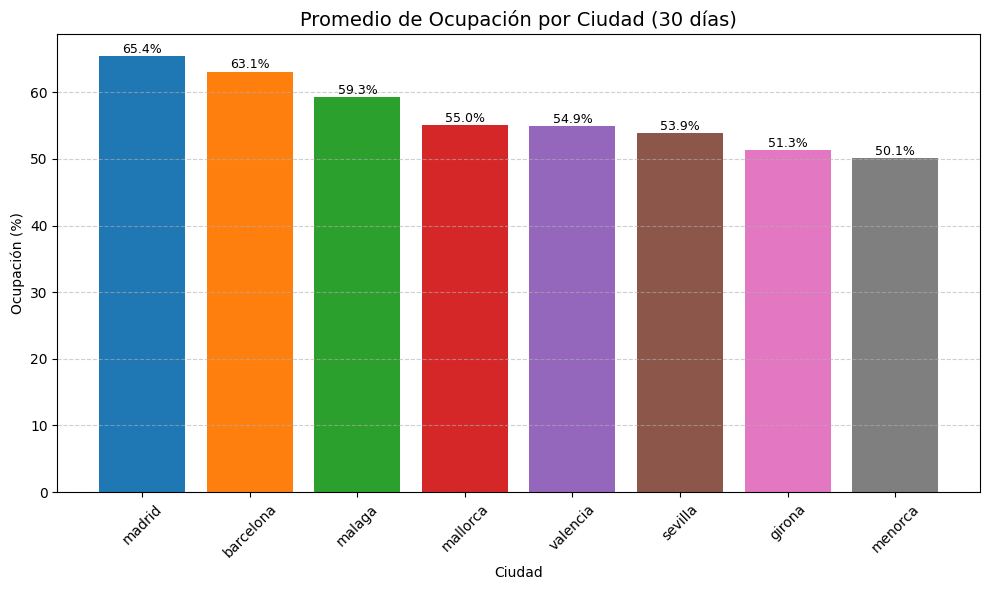

In [29]:
import matplotlib.pyplot as plt
# Ordenar de mayor a menor
promedio_ciudad_30 = promedio_ciudad_30.sort_values(ascending=False)

# Colores (uno por barra)
colors = plt.cm.tab10(range(len(promedio_ciudad_30)))

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.bar(promedio_ciudad_30.index, promedio_ciudad_30.values, color=colors)

plt.title("Promedio de Ocupación por Ciudad (30 días)", fontsize=14)
plt.ylabel("Ocupación (%)")
plt.xlabel("Ciudad")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Mostrar valores encima de cada barra
for i, v in enumerate(promedio_ciudad_30.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

tasa de ocupación mensual

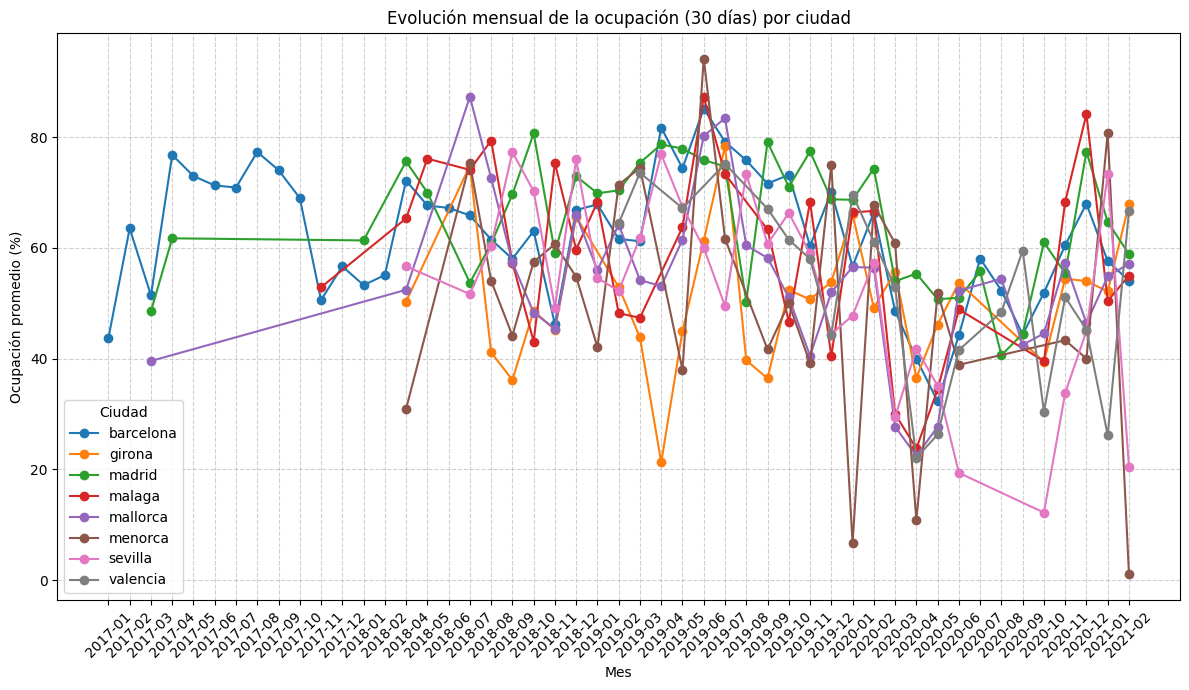

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for city in monthly_city["city"].unique():
    data_city = monthly_city[monthly_city["city"] == city]
    plt.plot(
        data_city["month"].astype(str),
        data_city["occupancy_rate_30"],
        marker="o",
        label=city
    )

plt.title("Evolución mensual de la ocupación (30 días) por ciudad")
plt.xlabel("Mes")
plt.ylabel("Ocupación promedio (%)")
plt.xticks(rotation=45)
plt.legend(title="Ciudad")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


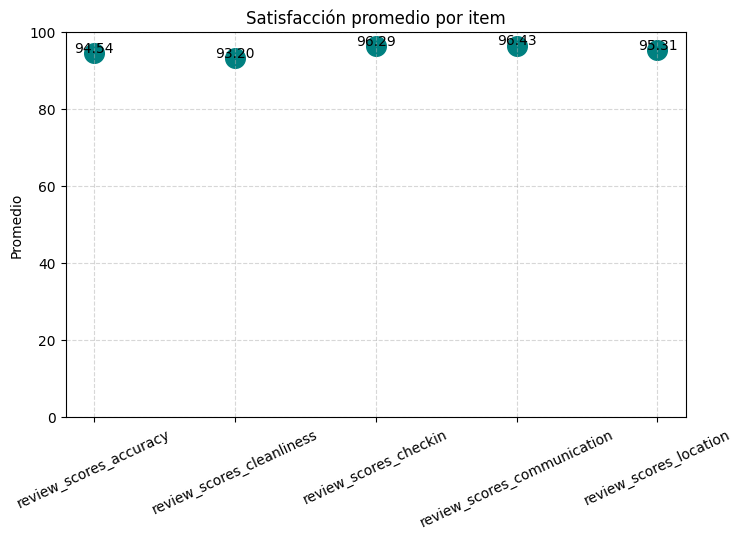

In [32]:
import matplotlib.pyplot as plt

# Datos
x = range(len(promedios))      # posiciones numéricas
y = promedios.values           # valores de promedio
labels = promedios.index       # nombres de los ítems

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='teal', s=200)  # s = tamaño del punto

# Añadir los valores encima de cada punto
for i, val in enumerate(y):
    plt.text(i, val + 0.3, f"{val:.2f}", ha='center', fontsize=10)

# Ajustar eje X para mostrar los nombres de los ítems
plt.xticks(x, labels, rotation=25)
plt.title("Satisfacción promedio por item")
plt.ylabel("Promedio")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
